# Tugas: Replikasi dan Analisis Skforecast Explainability

### Libraries and Data

Menginstall Library yang akan digunakan

- `skforecast` — library khusus untuk time series forecasting berbasis scikit-learn
- `lightgbm` — algoritma gradient boosting berbasis pohon keputusan, digunakan sebagai regressor internal
- `shap` — library untuk menghitung nilai SHAP (SHapley Additive exPlanations) guna menjelaskan prediksi model

In [ ]:
!pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.3/467.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 26.8 MB/s eta 0:00:00


In [ ]:
!pip install skforecast lightgbm shap

### Import Library

Mengimport semua library yang diperlukan

In [ ]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

### Load Dataset

Mendonwload dataset yang akan digunakan yaitu dataset `vic_electricity` dari repositori skforecast. Dataset ini berisi data konsumsi energi listrik di Victoria, Australia, diukur setiap 30 menit. Kolom utamanya adalah Demand (permintaan energi dalam megawatt)

In [ ]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


### Preprocessing Data

In [ ]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


### Split Data: Training & Testing

In [ ]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test = data.loc['2014-12-22':]

### Membuat dan Melatih forecaster

Model peramalan dibuat untuk memprediksi permintaan energi menggunakan 7 nilai sebelumnya (minggu lalu) dan suhu sebagai variabel eksogen

In [ ]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 7
             )

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-10 07:17:16 
Last fit date: 2026-06-10 07:17:16 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

### Extract fitur penting from trained forecaster

In [ ]:
# Predictors importances
# ==============================================================================
forecaster.get_feature_importances()

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


### Matriks Training

In [ ]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


,y
Time,
2012-01-07,200693.270298
2012-01-08,200061.614738
2012-01-09,216201.836844


### Shap explainer

In [ ]:
# Create SHAP explainer
# ==============================================================================
shap.initjs()
explainer = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

### Shap Summary Plot

Plot ringkasan yang menampilkan pentingnya fitur atau kontribusi setiap fitur terhadap output model di berbagai titik data. Plot ini menunjukkan seberapa besar kontribusi setiap fitur dalam menjauhkan prediksi model dari nilai dasar (seringkali prediksi rata-rata model)

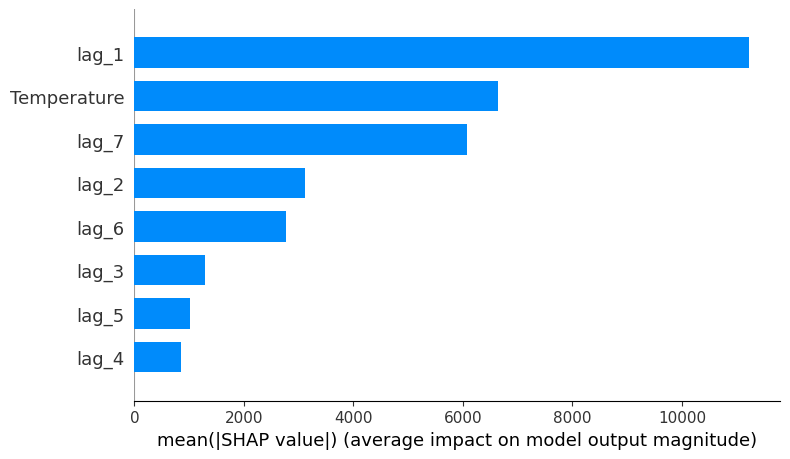

In [ ]:
shap.summary_plot(shap_values, X_train, plot_type="bar")

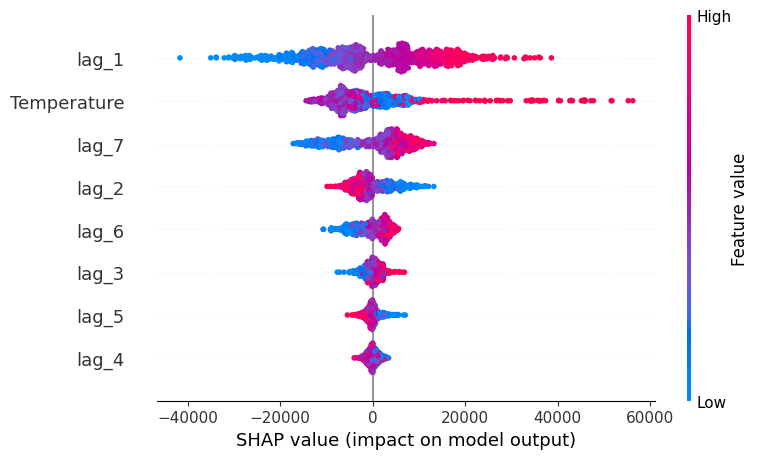

In [ ]:
shap.summary_plot(shap_values, X_train)

### Visualisasi Single Prediction

`shap.force_plot` adalah jenis visualisasi spesifik yang memberikan tampilan interaktif dan detail tentang bagaimana fitur-fitur individual berkontribusi pada prediksi tertentu yang dibuat oleh model pembelajaran mesin.

In [ ]:
# Inisialisasi JavaScript untuk SHAP (wajib dijalankan sekali di setiap notebook)
shap.initjs()

# Force plot untuk observasi pertama
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[0, :], X_train.iloc[0, :])

### Visualisasi Many Predictions

In [ ]:
# Inisialisasi JavaScript untuk SHAP
shap.initjs()

# Force plot untuk 200 observasi pertama
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

### Shap Dependence Plot

Plot SHAP dependence adalah visualisasi yang digunakan untuk memahami hubungan antara suatu fitur dan keluaran model dengan menampilkan bagaimana nilai suatu fitur tunggal memengaruhi prediksi yang dibuat oleh model sambil mempertimbangkan interaksi dengan fitur lain.

Plot ini berguna untuk memeriksa bagaimana fitur tertentu memengaruhi prediksi model di seluruh rentang nilainya dengan mempertimbangkan interaksi dengan variabel lain.




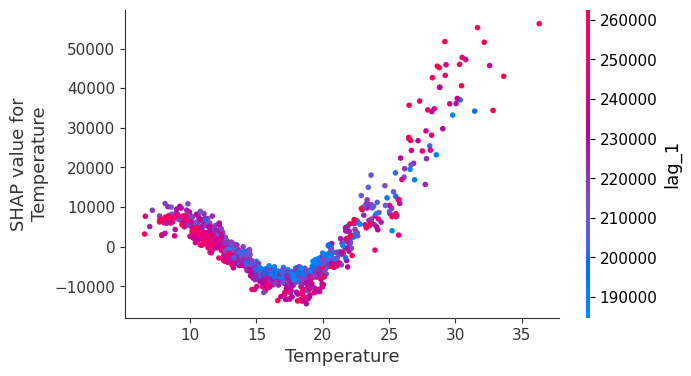

In [ ]:
# Dependence plot for Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot("Temperature", shap_values, X_train, ax=ax)

### Nilai-Nilai yang di Prediksi

Nilai SHAP juga dapat digunakan untuk menjelaskan nilai yang diprediksi. Hal ini dapat dilakukan dengan menggunakan matriks input yang digunakan oleh `predict` metode peramalan.

In [ ]:
# Predict
# ==============================================================================
predictions = forecaster.predict(steps=10, exog=data_test['Temperature'])
predictions

,pred
2014-12-22,241514.532543
2014-12-23,226165.936559
2014-12-24,220506.468700
2014-12-25,209260.948991
2014-12-26,184885.145832
2014-12-27,195623.591810
2014-12-28,222766.340659
2014-12-29,223112.716406
2014-12-30,219103.891733
2014-12-31,217948.965404


In [ ]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(steps=10, exog=data_test['Temperature'])
X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


In [ ]:
# Inisialisasi JavaScript untuk SHAP
shap.initjs()

# Force plot for a specific prediction
# ==============================================================================
predicted_date = '2014-12-22'
iloc_predicted_date = X_predict.index.get_loc(predicted_date)
shap_values = explainer.shap_values(X_predict)
shap.force_plot(
    explainer.expected_value,
    shap_values[iloc_predicted_date, :],
    X_predict.iloc[iloc_predicted_date, :]
)

### Mutasi Feature Important

Pentingnya fitur mutasi adalah teknik inspeksi model yang mengukur kontribusi setiap fitur terhadap kinerja statistik model yang dipasang pada dataset tabular tertentu.

Teknik ini sangat berguna untuk estimator non-linear atau buram, dan melibatkan pengacakan nilai-nilai dari satu fitur secara acak dan mengamati penurunan skor model yang dihasilkan.

Dengan memutus hubungan antara fitur dan variabel target, kita menentukan seberapa besar model bergantung pada fitur tertentu tersebut.

In [ ]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
                       y    = data_train['Demand'],
                       exog = data_train['Temperature']
                   )

# Permutation importances
# ==============================================================================
r = permutation_importance(
        estimator    = forecaster.estimator,
        X            = X_train,
        y            = y_train,
        n_repeats    = 3,
        max_samples  = 0.5,
        random_state = 123
    )

importances = pd.DataFrame({
                  'feature': X_train.columns,
                  'mean_importance': r.importances_mean,
                  'std_importance': r.importances_std
              }).sort_values('mean_importance', ascending=False)
importances

,feature,mean_importance,std_importance
0,lag_1,0.617276,0.014583
7,Temperature,0.411240,0.014405
6,lag_7,0.196190,0.001865
1,lag_2,0.122398,0.007803
5,lag_6,0.083912,0.003637
2,lag_3,0.041294,0.002019
4,lag_5,0.030787,0.001079
3,lag_4,0.024816,0.001021


### Plot Dependence Partial

 (PDP) adalah alat yang berguna untuk memahami hubungan antara suatu fitur dan hasil target dalam model pembelajaran mesin. Di `scikit-learn`,  dapat membuat plot ketergantungan parsial menggunakan `plot_partial_dependence` fungsi tersebut.

 Grafik yang dihasilkan menunjukkan bagaimana perubahan pada fitur yang dipilih memengaruhi hasil prediksi dengan mempertahankan fitur lain tetap konstan secara rata-rata.

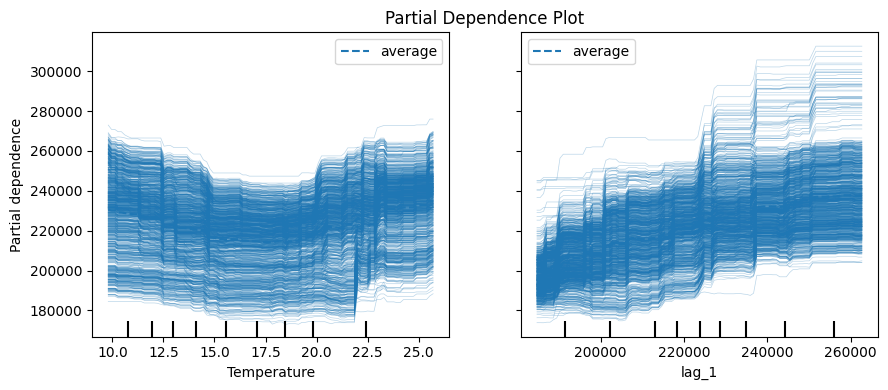

In [ ]:
# Scikit-learn partial dependence plots
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_title("Decision Tree")
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = X_train,
    features  = ["Temperature", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout();

## Jawaban Pertanyaan

### 1. Analisa prediksi tentang apa?

Analisis prediksi ini melakukan prediksi konsumsi energi listrik (electricity demand) berdasarkan data time series historis. Model meramalkan nilai konsumsi di masa depan menggunakan nilai-nilai konsumsi di masa lalu (lag).

Tujuan utama tutorial bukan hanya membuat prediksi yang akurat, tetapi juga menjelaskan mengapa model membuat prediksi tertentu - yaitu fitur mana yang paling berpengaruh terhadap hasil prediksi.

### 2. Bagaimana bentuk data trainingnya ( apa saja inputnya dan apa outpunya)

Sebelum dimasukkan ke dalam model regresi, `skforecast` mengubah data time series asli menjadi matriks tabular. Berdasarkan fungsi `create_train_X_y`, bentuknya adalah:




*   Input ($X$): Nilai lag dari time series: lag_1, lag_2, ..., lag_n — yaitu nilai konsumsi energi pada 1 jam lalu, 2 jam lalu, dst

*   Output ($y$): Nilai target yang ingin diprediksi pada waktu $t$, yaitu nilai Demand (Permintaan Listrik)



### 3. Apa itu Lag?

Lag adalah nilai historis (nilai masa lalu) dari variabel target itu sendiri yang digeser mundur berdasarkan interval waktu tertentu.

Contoh: Jika kita memprediksi permintaan listrik hari ini ($t$) dengan lags=7, maka model akan menggunakan data permintaan listrik 1 hari lalu ($t-1$), 2 hari lalu ($t-2$), hingga 7 hari lalu ($t-7$) sebagai fitur input.



### 4.  Jelaskan proses analysis yang dilakukan dari kasus diatas



1.   Transformasi Data (Windowing): skforecast mengambil data deret waktu mentah dan mengubahnya menjadi format matriks yang bisa dibaca oleh algoritma Machine Learning standar dengan cara mengekstrak lags dan menyandingkannya dengan variabel eksogen (Temperature)
2.   Pelatihan Model (Training): Model LGBMRegressor dilatih menggunakan matriks input tersebut untuk mempelajari hubungan nonlinear antara suhu, data historis (lags), dan total permintaan listrik
3. Global Interpretability (Permutation Importance & SHAP Summary):

    - Permutation Importance dilakukan untuk melihat fitur mana yang paling krusial dengan cara mengacak nilai fitur tersebut dan mengukur seberapa besar penurunan akurasi model.

    - SHAP Summary Plot digunakan untuk melihat arah pengaruh fitur. Kita bisa melihat apakah suhu yang tinggi memicu peningkatan permintaan listrik (akibat penggunaan AC, misalnya)
4. Local Interpretability (SHAP Force Plot): Dilakukan analisis mendalam pada observasi/waktu tertentu secara spesifik untuk melihat alasan mengapa model memprediksi angka yang tinggi atau rendah pada jam/hari tersebut.



